In [63]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time
from latcom.utils.optical_loading import pwv_interp
import latcom.utils.optical_loading as ol
from latcom.utils.parsing import parse_neps
import warnings
from pathlib import Path
import datetime as dt
from zoneinfo import ZoneInfo
import socolors

pwv = pwv_interp()


with open("../../nets/neps_09112026.pk", "rb") as f:
    nep_dict = pk.load(f)


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
nep_dict.keys()

dict_keys(['uv38', 'uv39', 'uv46', 'mv21', 'mv24', 'mv28', 'uv54', 'uv58', 'uv60', 'mv13', 'mv20', 'mv34', 'mv14', 'mv32', 'mv49', 'uv31', 'uv42', 'uv47', 'mv11', 'mv25', 'mv26', 'uv57', 'uv59', 'uv62', 'mv29', 'mv68', 'mv73', 'mv65', 'mv67', 'mv75', 'mv15r2', 'mv64', 'mv70', 'mv63', 'mv76', 'mv77', 'ln2', 'ln3', 'ln4'])

In [4]:
ufms = {key:{} for key in nep_dict.keys()}
for key in ufms.keys():
    ufms[key] = {subkey:[] for subkey in nep_dict[key].keys()}
    for subkey in ufms[key].keys():
        for nep in nep_dict[key][subkey]["neps"]:
            try:
                ufms[key][subkey].append(float(np.nanmean(nep[nep!=0])))
            except RuntimeWarning:
                continue

/tmp/ipykernel_2325793/649781989.py:7: RuntimeWarning: Mean of empty slice
  ufms[key][subkey].append(float(np.nanmean(nep[nep!=0])))


In [5]:
t_split = Time("2026-01-01T00:00:00", format="isot", scale="utc")


In [6]:
labels = []
neps = []
obs = []
pwv_sin_els = []
t_obs = []
period = []
df_ufms = []


pwv = pwv_interp()

freqs = ["030", "040", "090", "150", "220", "280"]
ufms = sorted(nep_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in nep_dict.keys():
            if ufm not in key:
                continue
            for sub_key in nep_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_obs = np.array(nep_dict[key][sub_key]["obs"])
                cur_neps = nep_dict[key][sub_key]["neps"]
                cur_pwv_sinel = np.array(nep_dict[key][sub_key]["pwv"]) / np.sin(np.deg2rad(np.array(nep_dict[key][sub_key]["el"])))
                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_neps)):
                    labels.append(label)
                    obs.append(cur_obs[j])
                    t_obs.append(int(cur_obs[j].split("_")[1]))
                    neps.append(float(np.nanmean(cur_neps[j][cur_neps[j]!=0]))*1e6)
                    pwv_sin_els.append(float(cur_pwv_sinel[j]))
                    df_ufms.append(ufm)
                    if int(cur_obs[j].split("_")[1]) < t_split.unix:
                        period.append("SO Nominal")
                    else:
                        period.append("ASO")

labels = np.array(labels)
obs = np.array(obs)
pwv_sin_els = np.array(pwv_sin_els)
neps = np.array(neps)
t_obs = np.array(t_obs)
period = np.array(period)
df_ufms = np.array(df_ufms)


df = pd.DataFrame(
    {
        "labels": labels,
        "obs": obs,
        "pwv_sin_els": pwv_sin_els,
        "neps": neps,
        "t_obs": t_obs,
        "Period": period,
        "ufms": df_ufms,
    }
)

/tmp/ipykernel_2325793/2047662858.py:33: RuntimeWarning: Mean of empty slice
  neps.append(float(np.nanmean(cur_neps[j][cur_neps[j]!=0]))*1e6)


In [7]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

(0.0, 60.0)

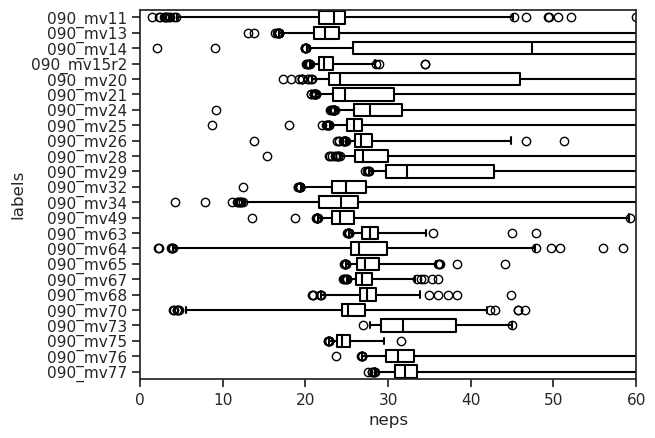

In [8]:
sns.boxplot(x="neps", y="labels",
            whis=[1,99], fill=False, color="black",
            data=df[(df.labels.str.contains("090")) & (df.pwv_sin_els<1.25) & (df.pwv_sin_els>0.7)])
plt.xlim(0,60)

# NEP vs PWV 

In [9]:
df["pwv_sinel_bin"] = pd.cut(df["pwv_sin_els"], bins=np.arange(0, 3.25, 0.25))

In [10]:
t_cut_low = Time("2026-05-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-10-16T00:00:00", format="isot", scale="utc")

t_cut_low_nominal = Time("2025-09-15T00:00:00", format="isot", scale="utc")
t_cut_high_nominal = Time("2025-12-16T00:00:00", format="isot", scale="utc")

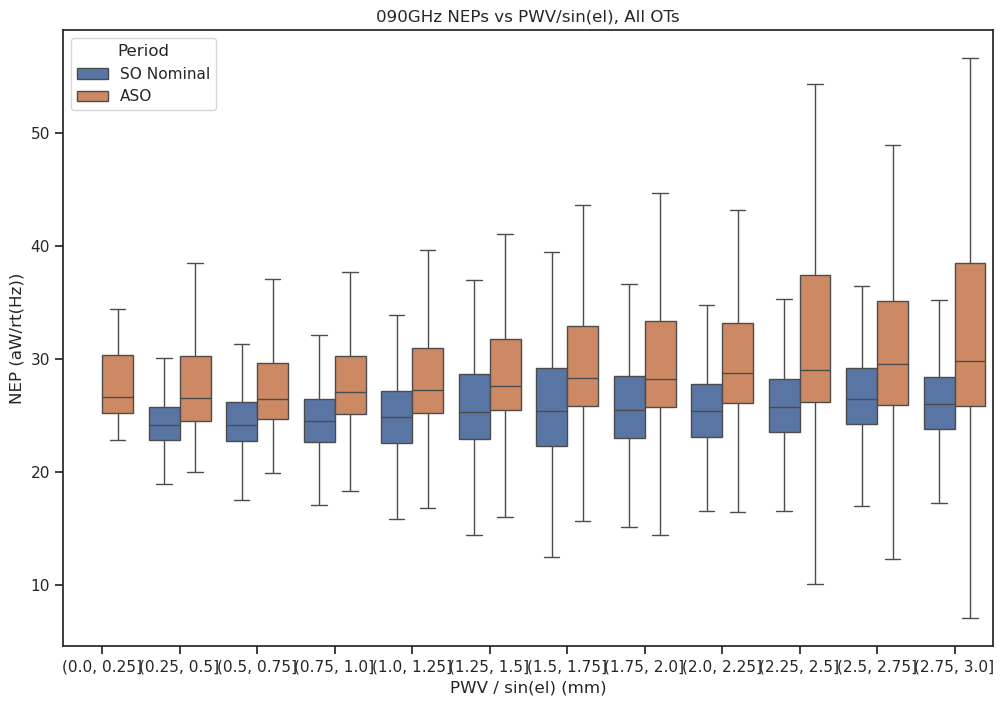

In [11]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df[df["labels"].str.contains("090")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("090GHz NEPs vs PWV/sin(el), All OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_090_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_090_vs_pwv_{}.pdf".format(date_str), dpi=600)

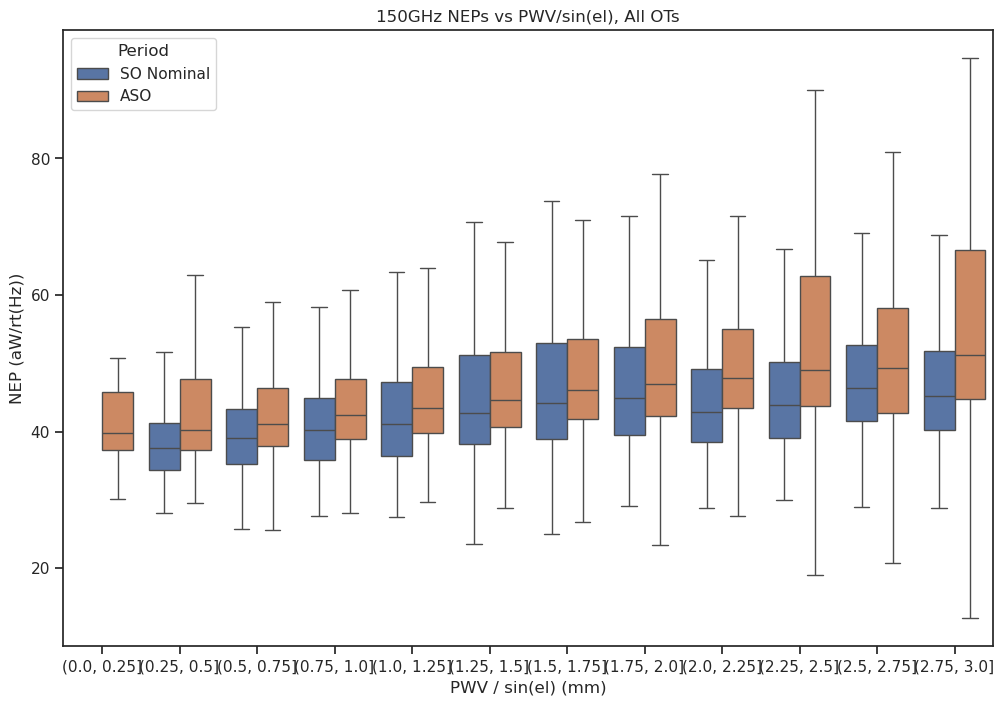

In [12]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df[df["labels"].str.contains("150")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("150GHz NEPs vs PWV/sin(el), All OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_150_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_150_vs_pwv_{}.pdf".format(date_str), dpi=600)

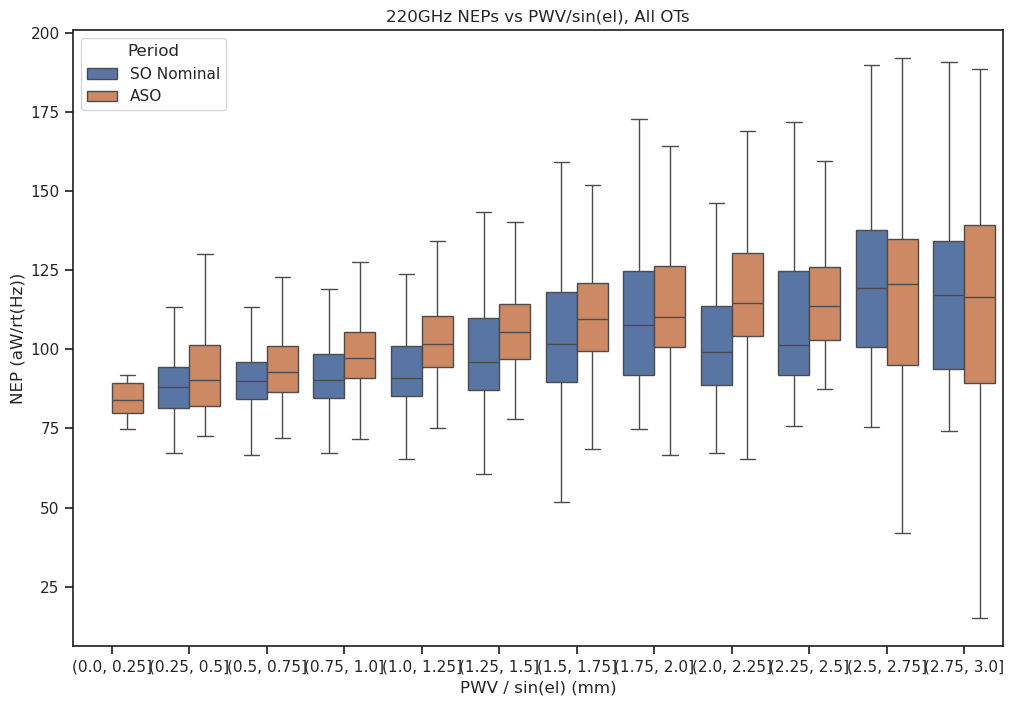

In [13]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df[df["labels"].str.contains("220")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("090GHz NEPs")

plt.title("220GHz NEPs vs PWV/sin(el), All OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_220_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_220_vs_pwv_{}.pdf".format(date_str), dpi=600)

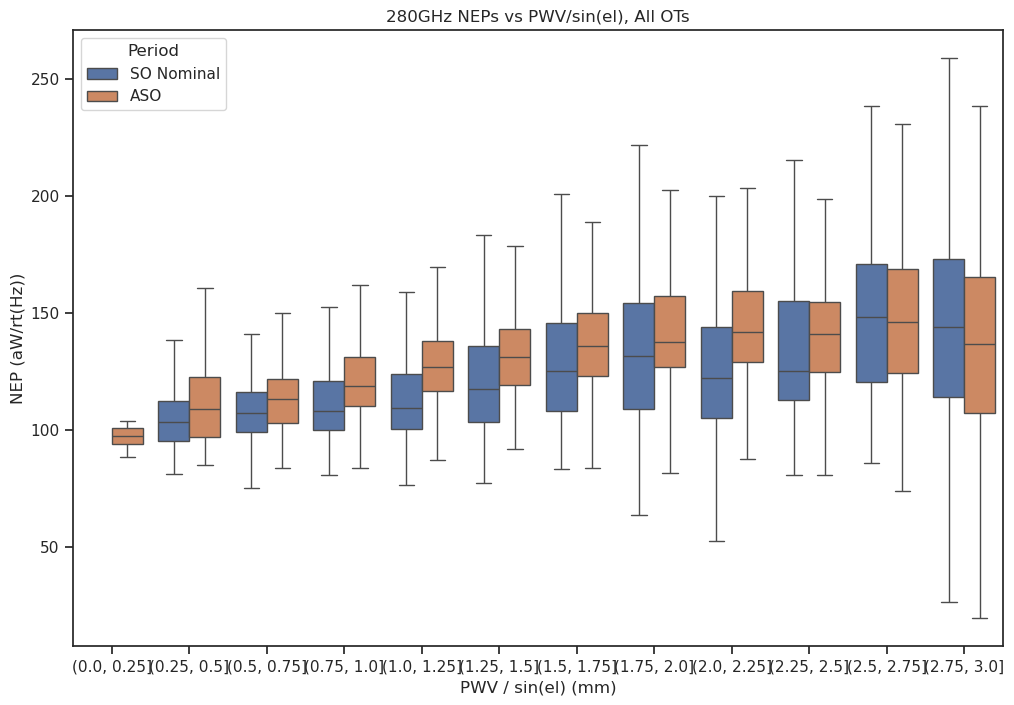

In [14]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df[df["labels"].str.contains("280")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")

plt.title("280GHz NEPs vs PWV/sin(el), All OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_280_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_280_vs_pwv_{}.pdf".format(date_str), dpi=600)

/tmp/ipykernel_2325793/3251241209.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(np.round(midpoints, 2), fontsize=10)
/tmp/ipykernel_2325793/3251241209.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(np.round(midpoints, 2), fontsize=10)
/tmp/ipykernel_2325793/3251241209.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklabels(np.round(midpoints, 2), fontsize=10)
/tmp/ipykernel_2325793/3251241209.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(np.round(midpoints, 2), fontsize=10)


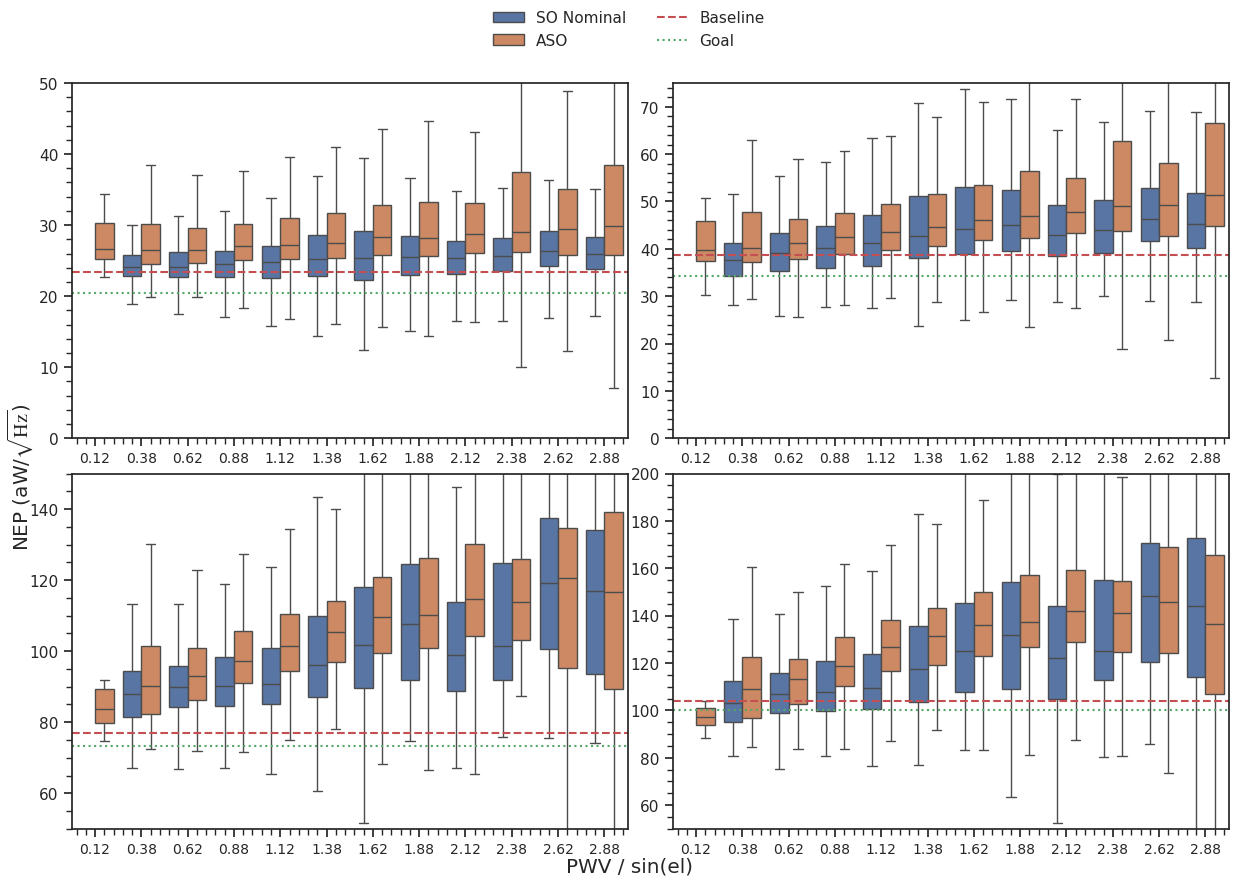

In [93]:
import socolors

f, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
c_base = "C3"
c_goal = "C2"
plt.style.use("apj-fullwidth")

midpoints = df["pwv_sinel_bin"].cat.categories.mid.tolist()

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df[df["labels"].str.contains("090")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
    ax=ax[0,0],
    legend=True,
)

sns.boxplot(
    data=df[df["labels"].str.contains("150")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
    ax=ax[0,1],
    legend=False,
)

sns.boxplot(
    data=df[df["labels"].str.contains("220")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
    ax=ax[1,0],
    legend=False
)

sns.boxplot(
    data=df[df["labels"].str.contains("280")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
    ax=ax[1,1],
    legend=False,
)

ax[0,0].axhline(y=23.417, label="Baseline", color=c_base, linestyle='--') #TODO: these NEP numbers are v4r0, want to replace with lat instrument model ones when I have them
ax[0,0].axhline(y=20.451, label="Goal", color=c_goal, linestyle=':')

ax[0,1].axhline(y=38.723, color=c_base, linestyle='--')
ax[0,1].axhline(y=34.205, color=c_goal, linestyle=':')

ax[1,0].axhline(y=76.892, color=c_base, linestyle='--')
ax[1,0].axhline(y=73.4, color=c_goal, linestyle=':')

ax[1,1].axhline(y=104, color=c_base, linestyle='--')
ax[1,1].axhline(y=100, color=c_goal, linestyle=':')

ax[0,0].set_xticklabels(np.round(midpoints, 2), fontsize=10)
ax[1,0].set_xticklabels(np.round(midpoints, 2), fontsize=10)
ax[0,1].set_xticklabels(np.round(midpoints, 2), fontsize=10)
ax[1,1].set_xticklabels(np.round(midpoints, 2), fontsize=10)

ax[0,0].set_ylim(0,50)
ax[0,1].set_ylim(0,75)
ax[1,0].set_ylim(50,150)
ax[1,1].set_ylim(50,200)

ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')
ax[1,0].set_xlabel('')
ax[1,1].set_xlabel('')

ax[0,0].set_ylabel('')
ax[0,1].set_ylabel('')
ax[1,0].set_ylabel('')
ax[1,1].set_ylabel('')

f.supylabel(r"NEP (aW/$\sqrt{\text{Hz}}$)", x=-0.02)
f.supxlabel(r"PWV / sin(el)")


handles_labels = {label: handle for handle, label in zip(*ax[0,0].get_legend_handles_labels())}
ax[0,0].get_legend().remove()
f.legend(handles_labels.values(), handles_labels.keys(), loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_all_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_all_vs_pwv_{}.pdf".format(date_str), dpi=600)

In [118]:
son_ufms = np.unique([ufms for ot, ufms in ol.ufm_dict.items() if ot in ol.so_nominal_tubes])
df_nom_tubes = df[df.ufms.isin(son_ufms)].reset_index(drop=True) 

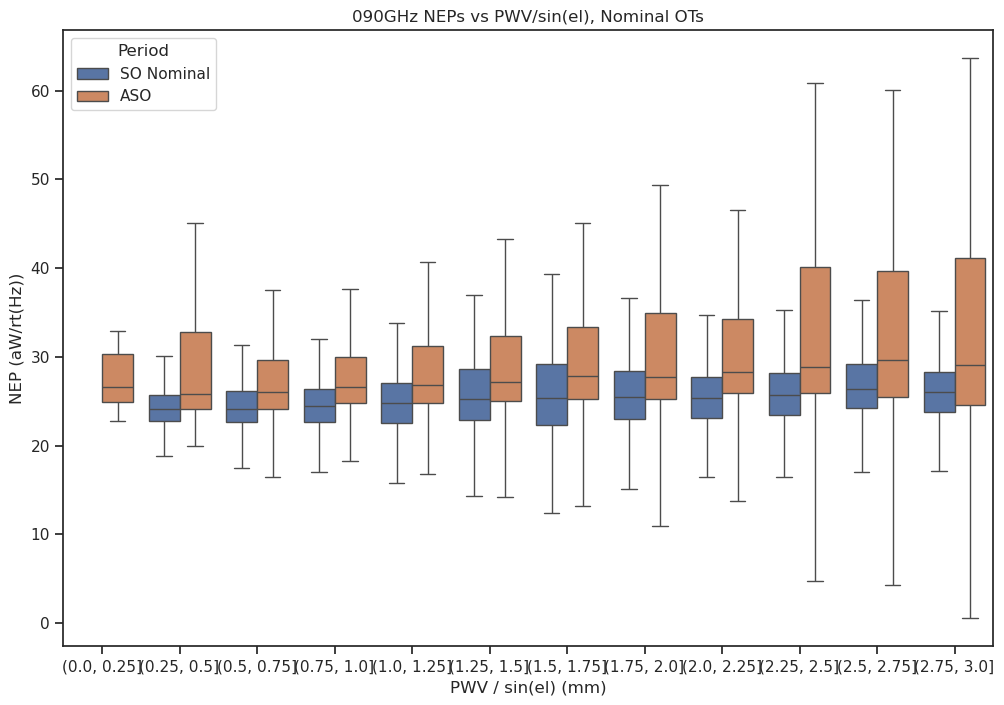

In [119]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df_nom_tubes[df_nom_tubes["labels"].str.contains("090")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("090GHz NEPs vs PWV/sin(el), Nominal OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_090_nominal_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_090_nominal_vs_pwv_{}.pdf".format(date_str), dpi=600)

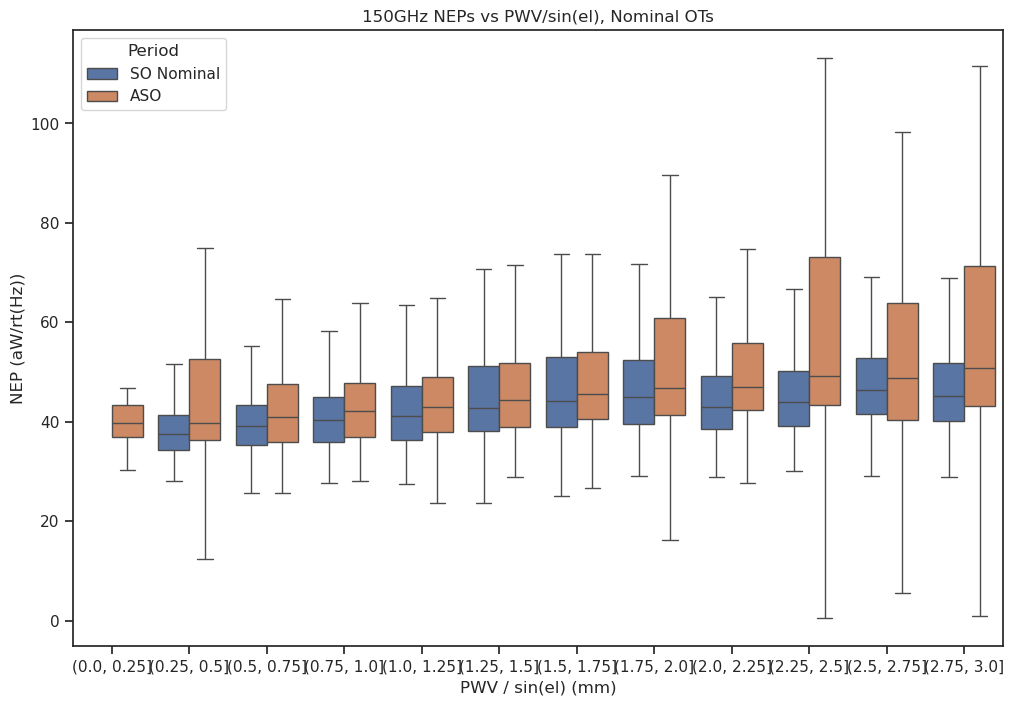

In [120]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df_nom_tubes[df_nom_tubes["labels"].str.contains("150")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("150GHz NEPs vs PWV/sin(el), Nominal OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_150_nominal_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_150_nominal_vs_pwv_{}.pdf".format(date_str), dpi=600)

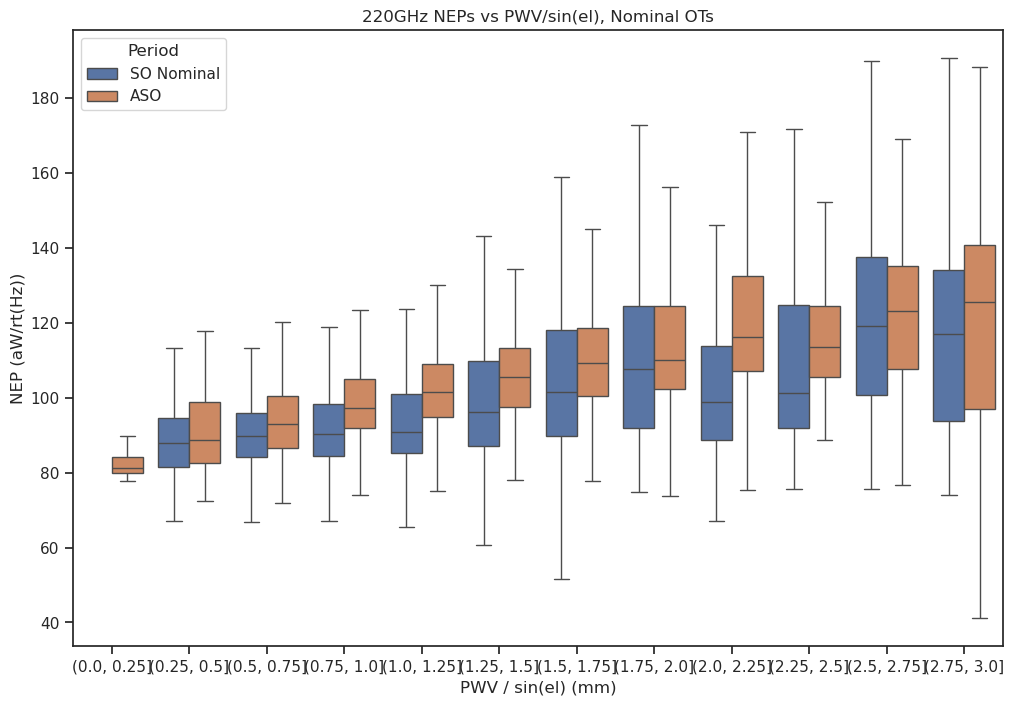

In [121]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df_nom_tubes[df_nom_tubes["labels"].str.contains("220")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("220GHz NEPs vs PWV/sin(el), Nominal OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_220_nominal_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_220_nominal_vs_pwv_{}.pdf".format(date_str), dpi=600)

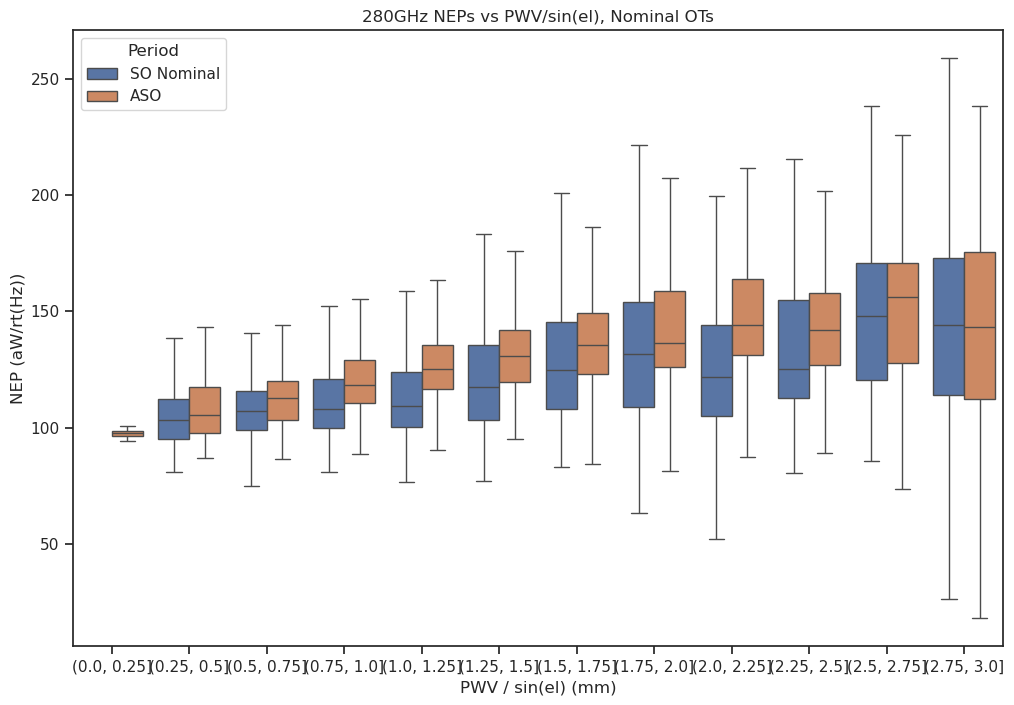

In [122]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=df_nom_tubes[df_nom_tubes["labels"].str.contains("280")],
    x="pwv_sinel_bin",
    y="neps",
    showfliers=False,
    hue="Period",
)


plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("280GHz NEPs vs PWV/sin(el), Nominal OTs")

output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)

today = dt.datetime.now(tz=ZoneInfo("America/New_York")).date()
date_str = str(today.month).zfill(2) + str(today.day).zfill(2) + str(today.year)

plt.savefig(output_dir / "NEPs_280_nominal_vs_pwv_{}.png".format(date_str), dpi=600)
plt.savefig(output_dir / "NEPs_280_nominal_vs_pwv_{}.pdf".format(date_str), dpi=600)